In [67]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [68]:

# k = symbols('omega', positive=True, real=True)
# l = symbols('s', positive=True, real=True)

# nu = symbols('nu', positive=True, real=True)

# a = symbols('A', positive=True, real=True)

# E = (S(2)/pi) * (a**2 / (a**2 + k**2))**((S(1) + S(2)*nu) / S(2))

# display(E.simplify())

# R = integrate(E * cos(k * l), (k, 0, oo))

# display(R.simplify())
# print_latex(R.simplify())

# SF = S(2) * limit(R, l, 0) - S(2) * R
# #limit(R, l, 0) = 1

# display(SF.simplify())
# print_latex(SF.simplify())

# # Gives the same thing
# #SF2 = 2 * integrate((1-cos(k*l))*E, (k, 0, oo))

# b = symbols('b', positive=True, real=True)

# eq_E = (1/b) * S(1)/S(2) * l**2 * diff(SF, l)

# display(eq_E.simplify())
# print_latex(eq_E.simplify())


In [69]:

k = symbols('omega', positive=True, real=True)
l = symbols('tau', positive=True, real=True)

nu = symbols('H', positive=True, real=True)
#nu = Rational(1,2)

#a = symbols('A', positive=True, real=True)
#a = sqrt(pi) * gamma(nu + S(1)/S(2))/gamma(nu)
a = S(25)

E = (S(2)/pi) * (a**2 / (a**2 + k**2))**((S(1) + S(2)*nu) / S(2))

display(E.simplify())

R = integrate(E * cos(k * l), (k, 0, oo))
display(R.simplify())

SF = S(2) * limit(R, l, 0) - S(2) * R
#limit(R, l, 0) = 1

display(SF.simplify())

# Gives the same thing
#SF2 = 2 * integrate((1-cos(k*l))*E, (k, 0, oo))
#display(SF2.simplify())

b = symbols('b', positive=True, real=True)

eq_E = (1/b) * S(1)/S(2) * l**2 * diff(SF, l)

display(eq_E.simplify())


50*5**(4*H)*(omega**2 + 625)**(-H - 1/2)/pi

5**(2*H + 2)*sqrt(pi)*(tau/2)**H*(besseli(-H, 25*tau) - besseli(H, 25*tau))/(sin(pi*H)*gamma(H + 1/2))

50*(2**H - (25*tau)**H*besseli(-H, 25*tau)*gamma(1 - H) + (25*tau)**H*besseli(H, 25*tau)*gamma(1 - H))*gamma(H)/(2**H*sqrt(pi)*gamma(H + 1/2))

5**(2*H + 2)*sqrt(pi)*(tau/2)**(H + 1)*(-2*H*besseli(-H, 25*tau) + 2*H*besseli(H, 25*tau) - 25*tau*besseli(1 - H, 25*tau) - 25*tau*besseli(-H - 1, 25*tau) + 25*tau*besseli(H - 1, 25*tau) + 25*tau*besseli(H + 1, 25*tau))/(b*sin(pi*H)*gamma(H + 1/2))

In [70]:
# eq = Eq(eq_E.simplify().subs({l: b/k}), E.simplify())
# display(eq)
# points = solve(eq, b)
# for p in points:
#     display(p)

In [71]:
# display(limit(eq_E.simplify(), nu, Rational(1,2)))

In [72]:

set1 = sqrt(pi) / (sin(pi*nu) * gamma(nu + Rational(1,2)))
display(set1.simplify())

set2 = -a*l*besseli(1-nu, a*l) - a*l*besseli(-nu-1,a*l) + a*l*besseli(nu-1,a*l) + a*l*besseli(nu+1,a*l)
display(set2.simplify())
display(limit(set2, nu, Rational(1,2)))

set3 = -2*nu*besseli(-nu, a*l) + 2*nu*besseli(nu, a*l)
display(set3.simplify())
#display(limit(set3, nu, 0))


sqrt(pi)/(sin(pi*H)*gamma(H + 1/2))

25*tau*(-besseli(1 - H, 25*tau) - besseli(-H - 1, 25*tau) + besseli(H - 1, 25*tau) + besseli(H + 1, 25*tau))

-25*tau*besseli(-3/2, 25*tau) + 25*tau*besseli(-1/2, 25*tau) - 25*tau*besseli(1/2, 25*tau) + 25*tau*besseli(3/2, 25*tau)

2*H*(-besseli(-H, 25*tau) + besseli(H, 25*tau))

/home/m/.local/lib/python3.10/site-packages/matplotlib/collections.py:196: RuntimeWarning: overflow encountered in cast
  offsets = np.asanyarray(offsets, float)


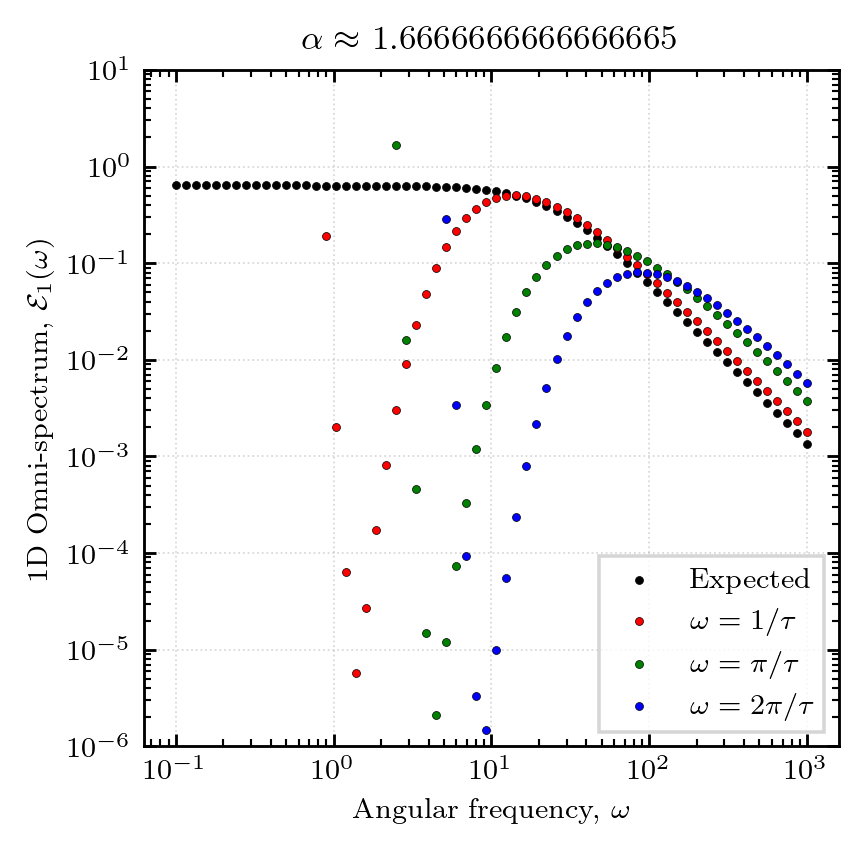

In [73]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_k = np.exp(np.linspace(np.log(0.1), np.log(1000), 64))
_nu = 1./3.

for __k in _k:
    val = E.subs({k: __k, nu: _nu}).evalf()
    ax.scatter(__k, val, marker='o', s=5., color='black', zorder=2, linewidth=0.2, edgecolor='black')

    val1 = eq_E.subs({l: 1./__k, nu: _nu, b: 1.}).evalf()
    ax.scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

    val2 = eq_E.subs({l: np.pi/__k, nu: _nu, b: np.pi}).evalf()
    ax.scatter(__k, val2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

    val3 = eq_E.subs({l: 2.*np.pi/__k, nu: _nu, b: 2.*np.pi}).evalf()
    ax.scatter(__k, val3, marker='o', s=5., color='blue', zorder=2, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.scatter([], [], marker='o', s=5., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax.scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$\omega = 1/\tau$')
ax.scatter([], [], marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$\omega = \pi / \tau$')
ax.scatter([], [], marker='o', s=5., color='blue', zorder=2, linewidth=0.2, edgecolor='black', label=r'$\omega = 2 \pi / \tau$')

ax.legend(frameon=True, fancybox=False)

ax.set_title(r'$\alpha \approx$ %s' % (1. + 2.*_nu))

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'1D Omni-spectrum, $\mathcal{E}_1(\omega)$')
ax.set_xlabel(r'Angular frequency, $\omega$')

ax.set_ylim((1e-6, 1e1))

fig.savefig('plots/semi_analytical_equiv_sf_ex.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/semi_analytical_equiv_sf_ex.png', transparent=True, bbox_inches='tight', pad_inches=0)


NameError: name 'alphas' is not defined

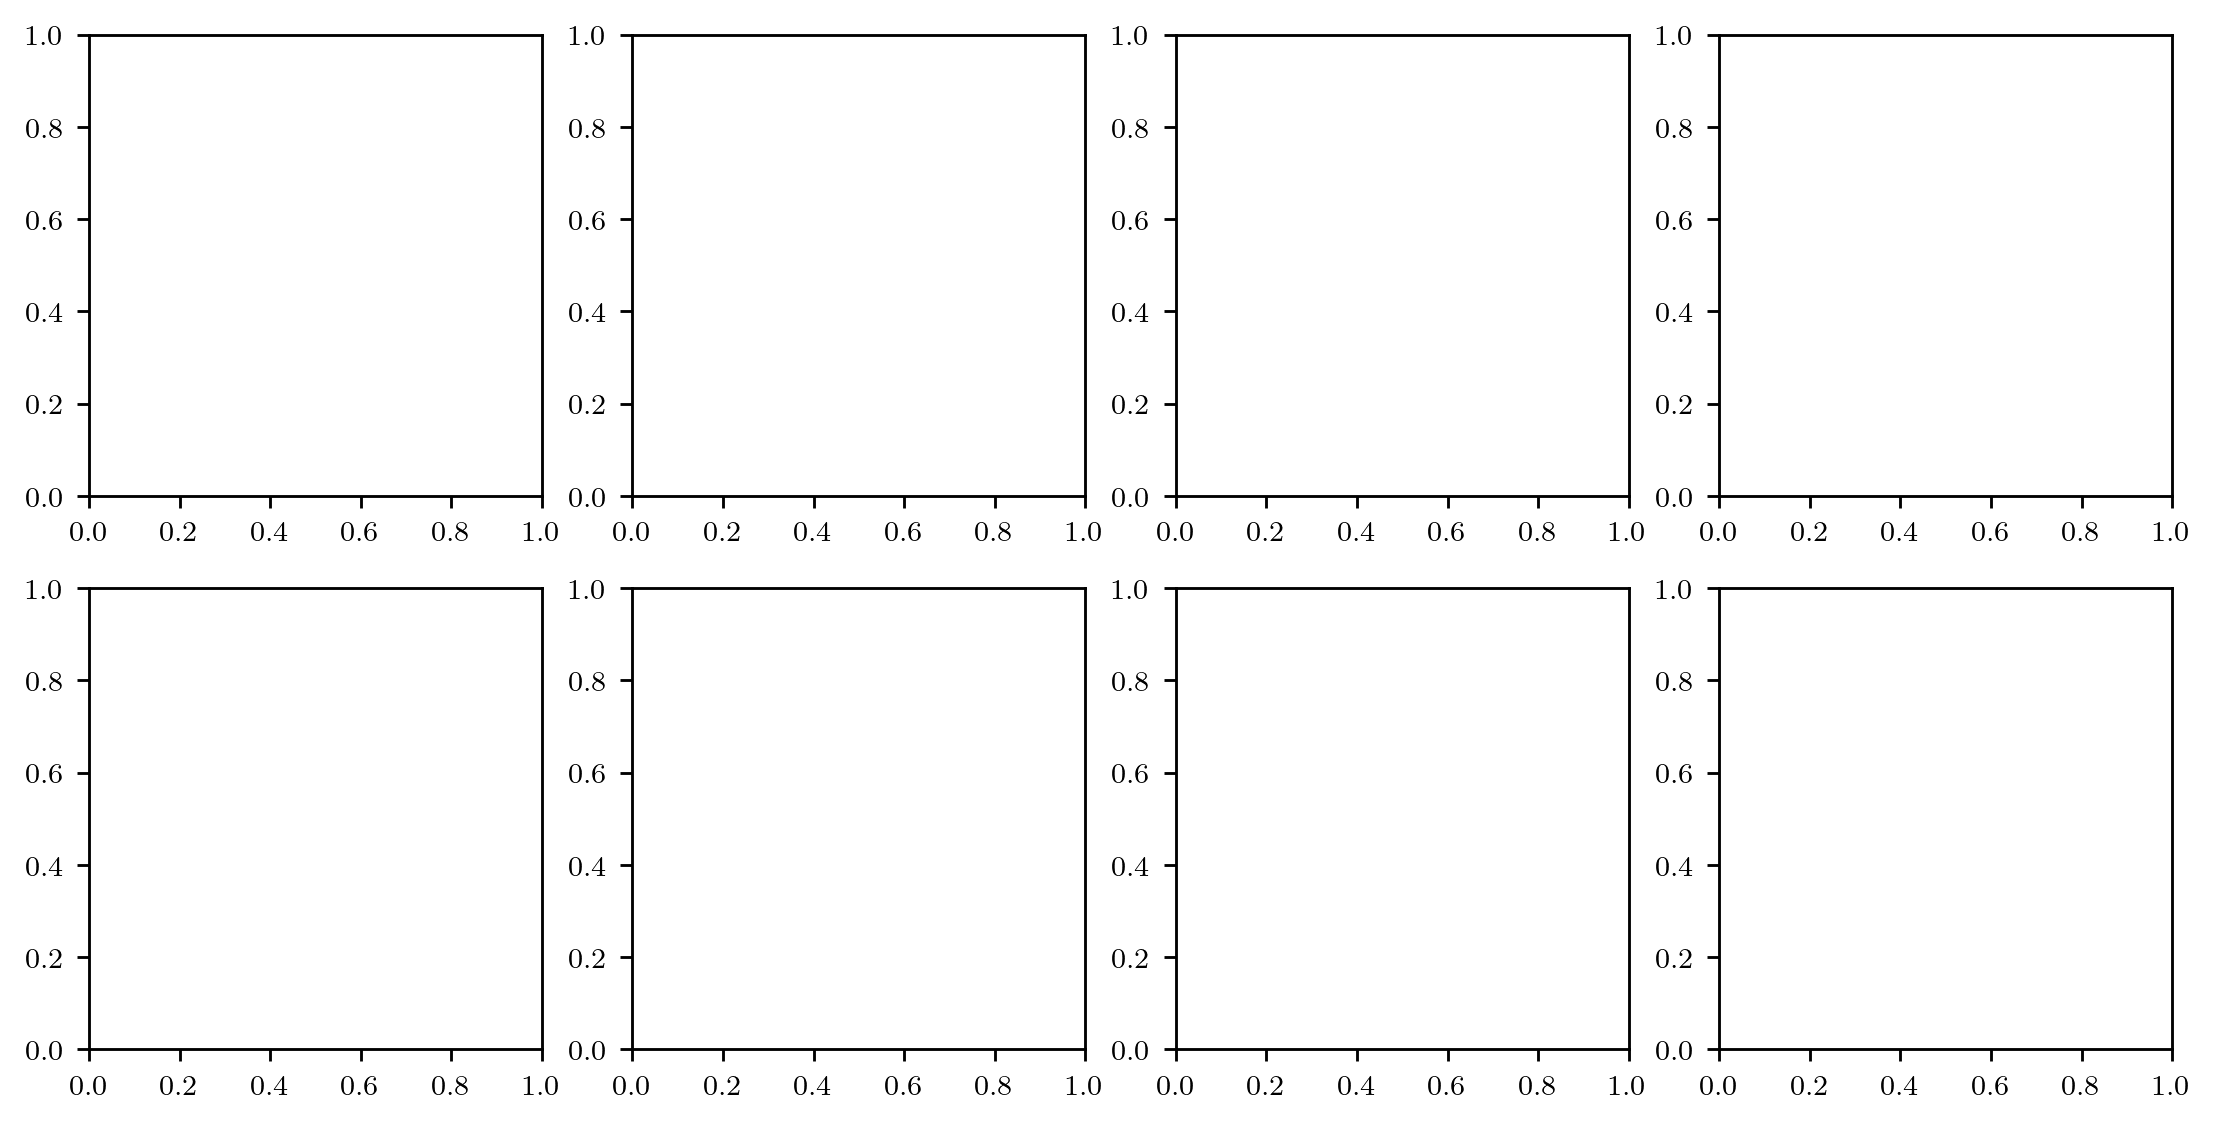

In [74]:

fig, ax = plt.subplots(2, 4, figsize=(3.5*3, 3.5*1.5), dpi=256)

i = 0
for j in range(2):
    for k in range(4):
        a = alphas[i]

        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color='black')
        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1., color='red')
        ax[j][k].plot(Especs_pipi[i][0], Especs_pipi[i][1], linewidth=1., color='blue')
        ax[j][k].plot(Especs_2pi2pi[i][0], Especs_2pi2pi[i][1], linewidth=1., color='green')

        ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0][0].plot([], [], linewidth=1., color='red', label=r'$\omega_e = 1/\tau$')
ax[0][0].plot([], [], linewidth=1., color='blue', label=r'$\omega_e = \pi/\tau$')
ax[0][0].plot([], [], linewidth=1., color='green', label=r'$\omega_e = 2 \pi/\tau$')
ax[0][0].legend()

ax[0][0].set_ylim((1e-5, 1e-1))
ax[0][1].set_ylim((1e-5, 1e-1))
ax[0][2].set_ylim((1e-5, 2e-1))
ax[0][3].set_ylim((1e-5, 2e-1))
#ax[0][4].set_ylim((1e-4, 4e0))

ax[1][0].set_ylim((1e-7, 2e-1))
ax[1][1].set_ylim((1e-7, 5e-1))
ax[1][2].set_ylim((1e-8, 5e-1))
ax[1][3].set_ylim((1e-8, 5e-1))
#ax[1][4].set_ylim((1e-6, 1e1))

fig.savefig('plots/equiv_sf_comparison_separate_bkn.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/equiv_sf_comparison_separate_bkn.png', transparent=True, bbox_inches='tight', pad_inches=0)


pi**(1/2 - nu/2)*(1/(2*omega))**(nu + 2)*(1/(nu*gamma(nu + 1/2)))**(nu + 1)*(pi*nu**2*gamma(nu + 1/2)**2 + omega**2*gamma(nu + 1)**2)**(nu + 1/2)*(-2*omega*besseli(-nu, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) + 2*omega*besseli(nu, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) - sqrt(pi)*besseli(1 - nu, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) - sqrt(pi)*besseli(-nu - 1, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + sqrt(pi)*besseli(nu - 1, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + sqrt(pi)*besseli(nu + 1, sqrt(pi)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2))*gamma(1 - nu)/(gamma(nu)*gamma(nu + 1)**nu)

pi**(nu/2 + 1/2)*(1/(2*omega))**(nu + 2)*(1/(nu*gamma(nu + 1/2)))**(nu + 1)*(pi*nu**2*gamma(nu + 1/2)**2 + omega**2*gamma(nu + 1)**2)**(nu + 1/2)*(-2*omega*besseli(-nu, pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) + 2*omega*besseli(nu, pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) - pi**(3/2)*besseli(1 - nu, pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) - pi**(3/2)*besseli(-nu - 1, pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + pi**(3/2)*besseli(nu - 1, pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + pi**(3/2)*besseli(nu + 1, pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2))*gamma(1 - nu)/(gamma(nu)*gamma(nu + 1)**nu)

pi**(nu/2 + 1/2)*omega**(-nu - 2)*(1/(nu*gamma(nu + 1/2)))**(nu + 1)*(pi*nu**2*gamma(nu + 1/2)**2 + omega**2*gamma(nu + 1)**2)**(nu + 1/2)*(-omega*besseli(-nu, 2*pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) + omega*besseli(nu, 2*pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1) - pi**(3/2)*besseli(1 - nu, 2*pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) - pi**(3/2)*besseli(-nu - 1, 2*pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + pi**(3/2)*besseli(nu - 1, 2*pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2) + pi**(3/2)*besseli(nu + 1, 2*pi**(3/2)*gamma(nu + 1/2)/(omega*gamma(nu)))*gamma(nu + 1/2))*gamma(1 - nu)/(2*gamma(nu)*gamma(nu + 1)**nu)

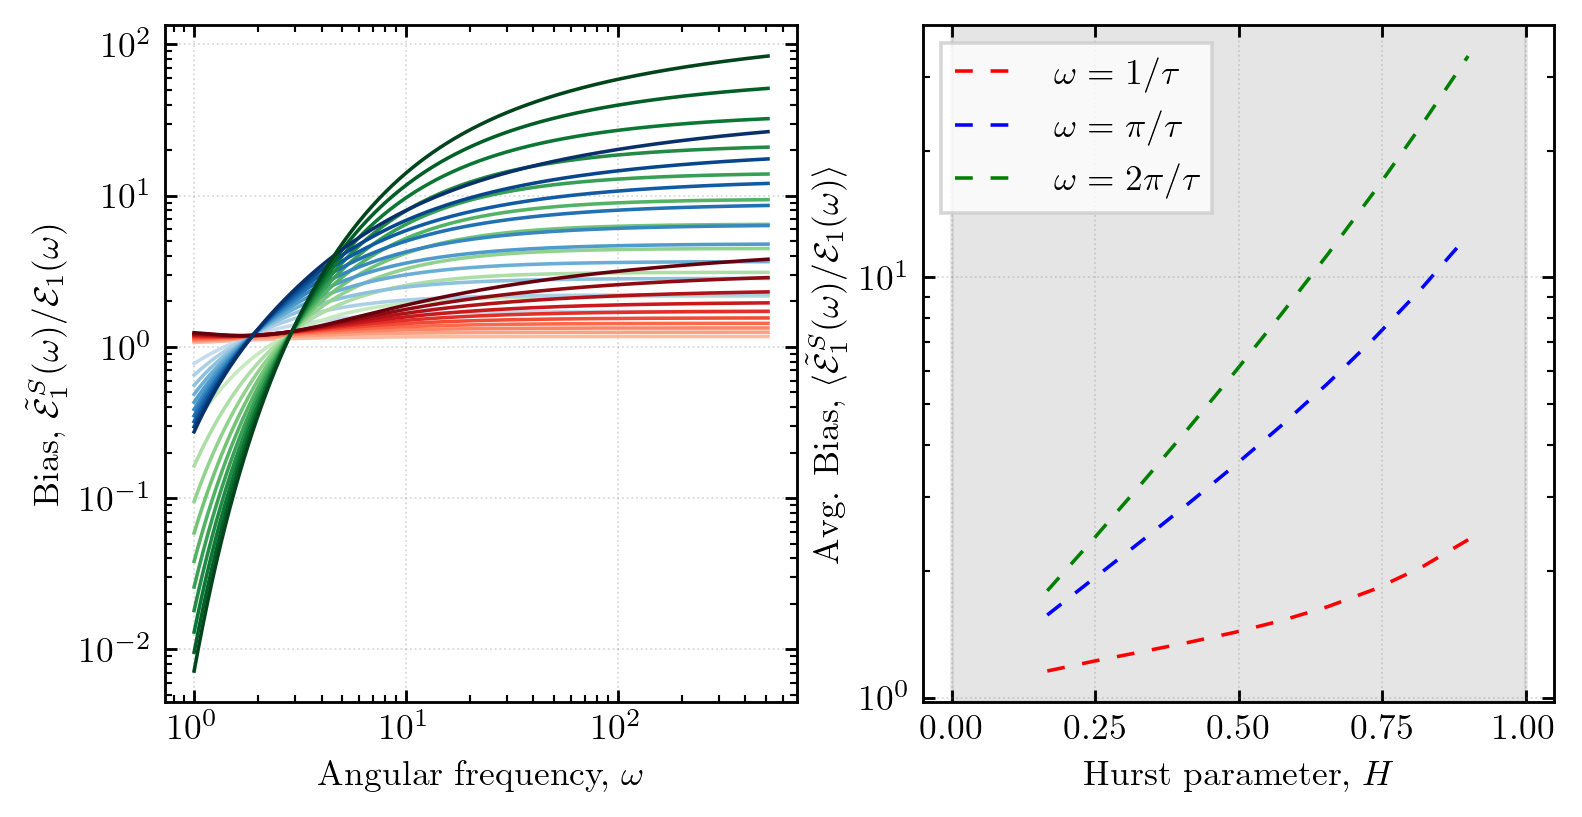

In [ ]:
NUM = 10
cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols1 = plt.cm.Reds(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols2)

fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256)

ratio1 = eq_E.subs({l: 1/k, b: 1}) / E
display(ratio1.simplify())

ratio2 = eq_E.subs({l: pi/k, b: pi}) / E
display(ratio2.simplify())

ratio3 = eq_E.subs({l: 2*pi/k, b: 2*pi}) / E
display(ratio3.simplify())

_k = np.exp(np.linspace(np.log(1), np.log(512), 256))
_nu = np.linspace(1./6., 0.9, NUM)

R1 = []
R2 = []
R3 = []
for i, __nu in enumerate(_nu):
    E0 = []

    E1 = []
    E2 = []
    E3 = []

    ER1 = []
    ER2 = []
    ER3 = []
    for __k in _k:
        val0 = E.subs({k: __k, nu: __nu}).evalf()
        E0.append(val0)

        val1 = eq_E.subs({l: 1./__k, nu: __nu, b: 1.}).evalf()
        E1.append(val1)
        val2 = eq_E.subs({l: np.pi/__k, nu: __nu, b: np.pi}).evalf()
        E2.append(val2)
        val3 = eq_E.subs({l: 2.*np.pi/__k, nu: __nu, b: 2.*np.pi}).evalf()
        E3.append(val3)

        val3 = ratio1.subs({k: __k, nu: __nu}).evalf()
        ER1.append(val3)
        val4 = ratio2.subs({k: __k, nu: __nu}).evalf()
        ER2.append(val4)
        val4 = ratio3.subs({k: __k, nu: __nu}).evalf()
        ER3.append(val4)

    E0 = np.array(E0)

    E1 = np.array(E1)
    E2 = np.array(E2)
    E3 = np.array(E3)

    R1.append(np.mean(np.array(ER1)))
    R2.append(np.mean(np.array(ER2)))
    R3.append(np.mean(np.array(ER3)))

    ax[0].plot(_k, E1/E0, color=cols1[i], linewidth=1.)
    ax[0].plot(_k, E2/E0, color=cols2[i], linewidth=1.)
    ax[0].plot(_k, E3/E0, color=cols3[i], linewidth=1.)
    #ax[1].scatter(__nu, np.mean(E2/E1), marker='X', s=5., color=cols1[i], zorder=2, linewidth=0.2, edgecolor='black')

ax[1].plot(_nu, R1, linewidth=1., color='red', zorder=1, linestyle=(0,(5,5)))
ax[1].plot(_nu, R2, linewidth=1., color='blue', zorder=1, linestyle=(0,(5,5)))
ax[1].plot(_nu, R3, linewidth=1., color='green', zorder=1, linestyle=(0,(5,5)))

ax[1].axvspan(0, 1., alpha=0.2, color='gray', zorder=0)

ax[0].loglog()
ax[1].set_yscale('log')

#ax[0].plot([], [], color='black', linewidth=1., label=r'Expected')
ax[1].plot([], [], linewidth=1., linestyle=(0,(5,5)), color='red', label=r'$\omega = 1/\tau$')
ax[1].plot([], [], linewidth=1., linestyle=(0,(5,5)), color='blue', label=r'$\omega = \pi /\tau$')
ax[1].plot([], [], linewidth=1., linestyle=(0,(5,5)), color='green', label=r'$\omega = 2\pi /\tau$')

ax[1].legend(frameon=True, fancybox=False)

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel(r'Bias, $\tilde{\mathcal{E}}_1^S(\omega)/\mathcal{E}_1(\omega)$')
ax[0].set_xlabel(r'Angular frequency, $\omega$')

ax[1].set_ylabel(r'Avg. Bias, $\langle \tilde{\mathcal{E}}_1^S(\omega)/\mathcal{E}_1(\omega) \rangle$')
ax[1].set_xlabel(r'Hurst parameter, $H$')
#ax.set_ylim((1e-6, 1e1))

fig.savefig('plots/semi_analytical_equiv_sf.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/semi_analytical_equiv_sf.png', transparent=True, bbox_inches='tight', pad_inches=0)
